In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# 解決 matplotlib 中文顯示問題
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS 使用 Arial Unicode MS
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

data = pd.read_csv('data_choice_complete.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45211 non-null  float64
 1   job        45211 non-null  float64
 2   marital    45211 non-null  float64
 3   education  45211 non-null  float64
 4   balance    45211 non-null  float64
 5   housing    45211 non-null  float64
 6   loan       45211 non-null  float64
 7   month      45211 non-null  float64
 8   duration   45211 non-null  float64
 9   campaign   45211 non-null  float64
 10  y          45211 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 3.8 MB


In [50]:
from sklearn.model_selection import train_test_split

X=data.drop('y', axis=1)
y=data['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((36168, 10), (9043, 10), (36168,), (9043,))

# 處理類別不平衡（重要！）

**問題**：訓練資料中「不訂閱」和「訂閱」的比例約 8:1，導致模型偏向預測「不訂閱」。

**解決方案**：使用 `class_weight` 或 SMOTE 平衡資料

In [51]:
# 檢查類別分布
print("=" * 60)
print("訓練資料類別分布:")
print("=" * 60)
print(y_train.value_counts())
print(f"\n比例: {y_train.value_counts()[0]} : {y_train.value_counts()[1]}")
print(f"不平衡比: {y_train.value_counts()[0] / y_train.value_counts()[1]:.2f} : 1")

# 計算 class_weight
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("\n" + "=" * 60)
print("計算的 class_weight:")
print("=" * 60)
print(f"類別 0 (不訂閱) 權重: {class_weight_dict[0]:.4f}")
print(f"類別 1 (訂閱) 權重:   {class_weight_dict[1]:.4f}")
print(f"\n說明: 訓練時，類別 1 的損失會被放大 {class_weight_dict[1]:.2f} 倍")
print("     這會強迫模型更重視少數類（訂閱客戶）")

訓練資料類別分布:
y
0    31913
1     4255
Name: count, dtype: int64

比例: 31913 : 4255
不平衡比: 7.50 : 1

計算的 class_weight:
類別 0 (不訂閱) 權重: 0.5667
類別 1 (訂閱) 權重:   4.2501

說明: 訓練時，類別 1 的損失會被放大 4.25 倍
     這會強迫模型更重視少數類（訂閱客戶）


# Neural Network 模型訓練
使用TensorFlow

In [52]:
%pip install tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import time
import numpy as np

# 設定隨機種子以便重現結果
np.random.seed(100)
tf.random.set_seed(100)

# 神經網路對特徵縮放敏感，先進行標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 記錄開始時間
start_time = time.time()

# 建立 TensorFlow/Keras 神經網路模型
print("=" * 60)
print("建立 TensorFlow 神經網路模型")
print("=" * 60)

nn_model = keras.Sequential([
    # 輸入層（自動推斷維度）
    layers.Input(shape=(X_train_scaled.shape[1],)),
    
    # 隱藏層
    layers.Dense(5, activation='tanh', name='hidden_layer_1'),
    layers.Dense(5, activation='tanh', name='hidden_layer_2'),
    layers.Dense(5, activation='tanh', name='hidden_layer_3'),
    layers.Dense(5, activation='tanh', name='hidden_layer_4'),
    
    # 輸出層：1個神經元 + Sigmoid 激活函數（用於二元分類）
    layers.Dense(1, activation='sigmoid', name='output_layer')
])

# 編譯模型
# optimizer='adam': 使用 Adam 優化器
# loss='binary_crossentropy': 二元分類的損失函數
# metrics=['accuracy']: 追蹤準確率
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision']
)

# 顯示模型架構
print("\n模型架構:")
nn_model.summary()

# 訓練模型
print("\n開始訓練...")
print("⚠️  使用 class_weight 處理類別不平衡")
print(f"   類別 1 的權重提高到 {class_weight_dict[1]:.2f} 倍\n")

history = nn_model.fit(
    X_train_scaled, 
    y_train,
    epochs=200,  # 訓練 300 個 epoch
    batch_size=32,  # 每批次 32 筆資料
    validation_split=0.2,  # 使用 20% 的訓練資料作為驗證集
    # class_weight=class_weight_dict,  # 🔥 加入 class_weight 處理不平衡
    verbose=1  # 顯示訓練過程
)

# 計算訓練時間
end_time = time.time()
training_time = end_time - start_time

# 預測（輸出機率值）
y_pred_proba_raw = nn_model.predict(X_test_scaled, verbose=0)
y_pred_proba_raw = y_pred_proba_raw.flatten()  # 展平為一維陣列

# 轉換為類別標籤（閾值 0.5）
y_pred_nn = (y_pred_proba_raw >= 0.5).astype(int)

# 計算準確率
nn_acc = accuracy_score(y_test, y_pred_nn)

# 輸出結果
print("\n" + "=" * 60)
print("Neural Network (TensorFlow) 訓練結果:")
print("=" * 60)
print(f"訓練時間: {training_time:.4f} 秒 ({training_time:.2f}s)")
print(f"準確率:   {nn_acc:.4f} ({nn_acc*100:.2f}%)")
print(f"最終訓練損失: {history.history['loss'][-1]:.4f}")
print(f"最終訓練準確率: {history.history['accuracy'][-1]:.4f}")
print(f"最終驗證損失: {history.history['val_loss'][-1]:.4f}")
print(f"最終驗證準確率: {history.history['val_accuracy'][-1]:.4f}")
print("\n分類報告:")
print(classification_report(y_test, y_pred_nn))


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
建立 TensorFlow 神經網路模型

模型架構:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_4 (Dense)          │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)


開始訓練...
⚠️  使用 class_weight 處理類別不平衡
   類別 1 的權重提高到 4.25 倍

Epoch 1/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 1s 557us/step - accuracy: 0.8725 - loss: 0.3503 - precision: 0.3685 - val_accuracy: 0.8784 - val_loss: 0.3000 - val_precision: 0.4701
Epoch 2/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - accuracy: 0.8847 - loss: 0.2910 - precision: 0.5250 - val_accuracy: 0.8796 - val_loss: 0.2905 - val_precision: 0.4861
Epoch 3/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step - accuracy: 0.8854 - loss: 0.2837 - precision: 0.5359 - val_accuracy: 0.8797 - val_loss: 0.2856 - val_precision: 0.4860
Epoch 4/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step - accuracy: 0.8861 - loss: 0.2804 - precision: 0.5483 - val_accuracy: 0.8813 - val_loss: 0.2834 - val_precision: 0.5141
Epoch 5/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - accuracy: 0.8861 - loss: 0.2789 - precision: 0.5499 - val_accuracy: 0.8811 - val_loss: 0.2824 - val_precision: 0.5119
Epoch 6/200
905/905 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step - accuracy

## 混淆矩陣

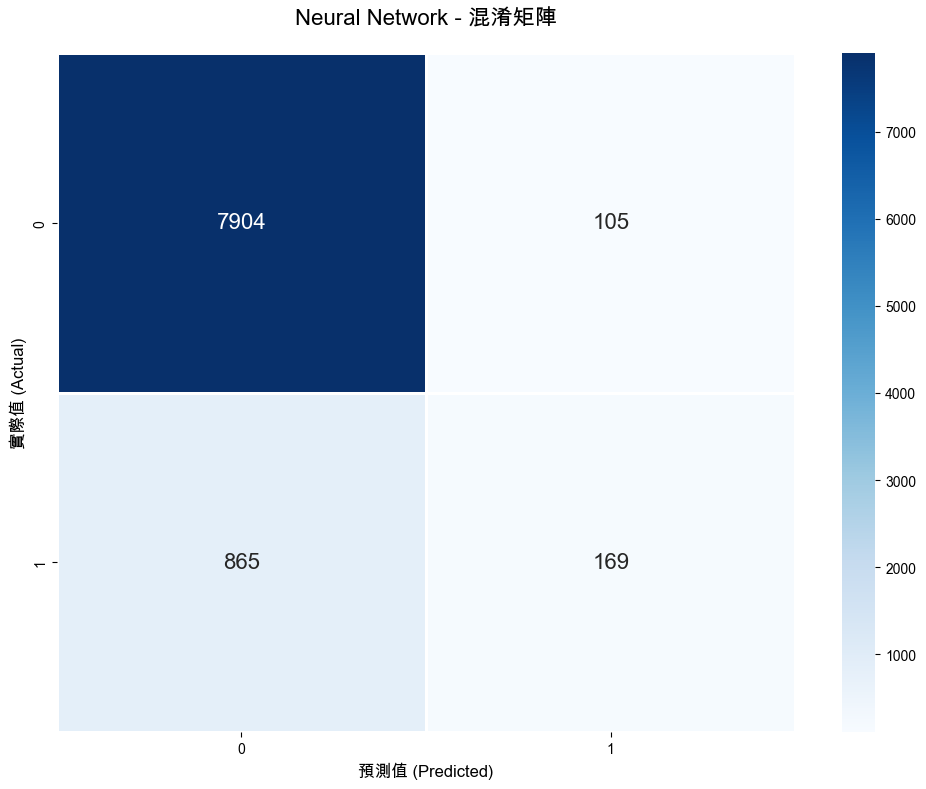

混淆矩陣分析:

True Negative (TN):   7904 - 正確預測為「未訂閱」
False Positive (FP):   105 - 錯誤預測為「訂閱」(Type I Error)
False Negative (FN):   865 - 錯誤預測為「未訂閱」(Type II Error)
True Positive (TP):    169 - 正確預測為「訂閱」

從混淆矩陣計算的評估指標:
準確率 (Accuracy):    0.8927 (89.27%)
  → (TP + TN) / 總數 = (169 + 7904) / 9043

精確率 (Precision):   0.6168 (61.68%)
  → TP / (TP + FP) = 169 / (169 + 105)
  → 預測為「訂閱」中，真正訂閱的比例

召回率 (Recall):      0.1634 (16.34%)
  → TP / (TP + FN) = 169 / (169 + 865)
  → 實際「訂閱」中，被正確找出的比例

特異度 (Specificity): 0.9869 (98.69%)
  → TN / (TN + FP) = 7904 / (7904 + 105)
  → 實際「未訂閱」中，被正確識別的比例

F1 分數 (F1-Score):   0.2584
  → 2 × (Precision × Recall) / (Precision + Recall)

業務意義解讀:
• Type I Error (FP=105):  誤判為會訂閱 → 浪費行銷資源
• Type II Error (FN=865): 漏掉潛在客戶 → 失去商機
• 如果重視「不錯過客戶」→ 提高 Recall (降低 FN)
• 如果重視「精準行銷」→ 提高 Precision (降低 FP)


In [53]:
import seaborn as sns

# 視覺化 Neural Network 的混淆矩陣
plt.figure(figsize=(10, 8))
cm_nn = confusion_matrix(y_test, y_pred_nn)

# 繪製混淆矩陣熱力圖
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', cbar=True, 
            annot_kws={'size': 16}, linewidths=2, linecolor='white')
plt.title('Neural Network - 混淆矩陣', fontsize=16, pad=20)
plt.ylabel('實際值 (Actual)', fontsize=12)
plt.xlabel('預測值 (Predicted)', fontsize=12)
plt.tight_layout()
plt.show()

# 詳細分析混淆矩陣
print("=" * 60)
print("混淆矩陣分析:")
print("=" * 60)

# 假設是二元分類 (0: 未訂閱, 1: 訂閱)
TN = cm_nn[0, 0]  # True Negative: 正確預測為 0
FP = cm_nn[0, 1]  # False Positive: 錯誤預測為 1 (Type I Error)
FN = cm_nn[1, 0]  # False Negative: 錯誤預測為 0 (Type II Error)
TP = cm_nn[1, 1]  # True Positive: 正確預測為 1

print(f"\nTrue Negative (TN):  {TN:5d} - 正確預測為「未訂閱」")
print(f"False Positive (FP): {FP:5d} - 錯誤預測為「訂閱」(Type I Error)")
print(f"False Negative (FN): {FN:5d} - 錯誤預測為「未訂閱」(Type II Error)")
print(f"True Positive (TP):  {TP:5d} - 正確預測為「訂閱」")

# 計算各項指標
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n" + "=" * 60)
print("從混淆矩陣計算的評估指標:")
print("=" * 60)
print(f"準確率 (Accuracy):    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  → (TP + TN) / 總數 = ({TP} + {TN}) / {TP+TN+FP+FN}")
print(f"\n精確率 (Precision):   {precision:.4f} ({precision*100:.2f}%)")
print(f"  → TP / (TP + FP) = {TP} / ({TP} + {FP})")
print(f"  → 預測為「訂閱」中，真正訂閱的比例")
print(f"\n召回率 (Recall):      {recall:.4f} ({recall*100:.2f}%)")
print(f"  → TP / (TP + FN) = {TP} / ({TP} + {FN})")
print(f"  → 實際「訂閱」中，被正確找出的比例")
print(f"\n特異度 (Specificity): {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  → TN / (TN + FP) = {TN} / ({TN} + {FP})")
print(f"  → 實際「未訂閱」中，被正確識別的比例")
print(f"\nF1 分數 (F1-Score):   {f1:.4f}")
print(f"  → 2 × (Precision × Recall) / (Precision + Recall)")

print("\n" + "=" * 60)
print("業務意義解讀:")
print("=" * 60)
print(f"• Type I Error (FP={FP}):  誤判為會訂閱 → 浪費行銷資源")
print(f"• Type II Error (FN={FN}): 漏掉潛在客戶 → 失去商機")
print(f"• 如果重視「不錯過客戶」→ 提高 Recall (降低 FN)")
print(f"• 如果重視「精準行銷」→ 提高 Precision (降低 FP)")

閾值優化分析:

當前閾值 = 0.5:
  Precision: 29.91%
  Recall:    81.62%
  F1-Score:  0.4378

✨ 最佳閾值 = 0.2248:
  Precision: 0.3934 (39.34%)
  Recall:    0.6547 (65.47%)
  F1-Score:  0.4915

  → F1-Score 提升: 0.0537 (+12.3%)

優化後的混淆矩陣:
True Negative (TN):   6965
False Positive (FP):  1044
False Negative (FN):   357
True Positive (TP):    677

準確率:  0.8451 (84.51%)
精確率:  0.3934 (39.34%)
召回率:  0.6547 (65.47%)
F1-Score: 0.4915


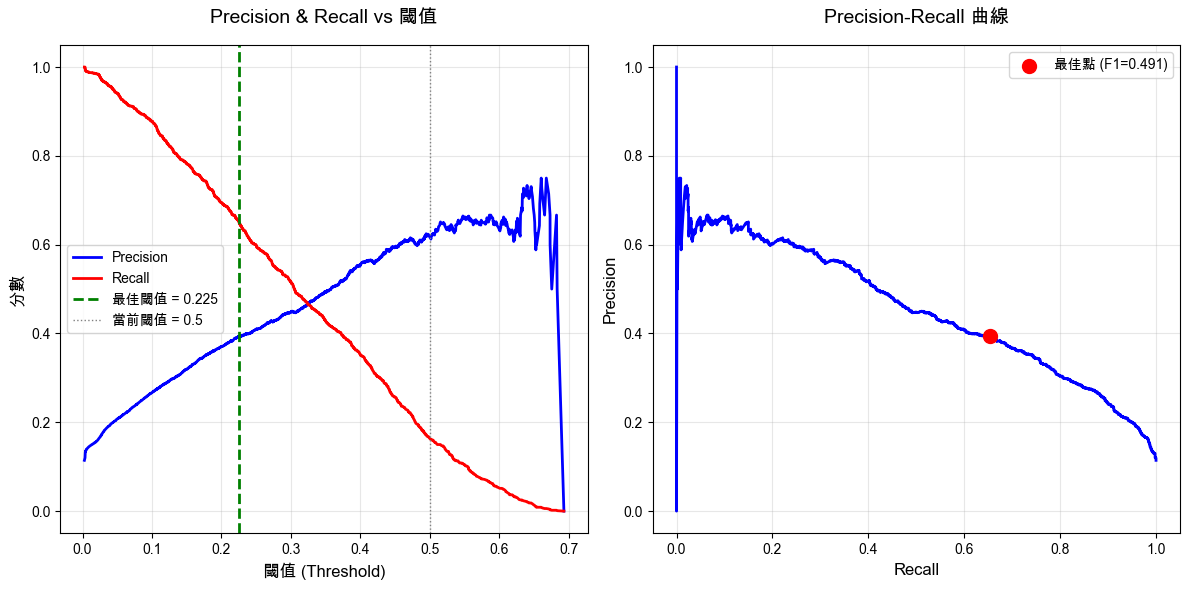


建議:
1. 使用閾值 0.2248 可以獲得最佳的 F1-Score
2. 這個閾值在 Precision 和 Recall 之間取得了最佳平衡
3. 根據業務需求，也可以選擇其他閾值：
   - 重視 Recall（不漏客戶）→ 降低閾值（例如 0.3）
   - 重視 Precision（精準行銷）→ 提高閾值（例如 0.6）


In [54]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 計算不同閾值下的 Precision 和 Recall
precision_values, recall_values, thresholds = precision_recall_curve(y_test, y_pred_proba_raw)

# 計算 F1-Score（排除最後一個點，因為沒有對應的閾值）
f1_scores = 2 * (precision_values[:-1] * recall_values[:-1]) / (precision_values[:-1] + recall_values[:-1] + 1e-10)

# 找出 F1-Score 最高的閾值
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx]
best_precision = precision_values[best_f1_idx]
best_recall = recall_values[best_f1_idx]
best_f1 = f1_scores[best_f1_idx]

print("=" * 70)
print("閾值優化分析:")
print("=" * 70)

print(f"\n當前閾值 = 0.5:")
print(f"  Precision: 29.91%")
print(f"  Recall:    81.62%")
print(f"  F1-Score:  0.4378")

print(f"\n✨ 最佳閾值 = {best_threshold:.4f}:")
print(f"  Precision: {best_precision:.4f} ({best_precision*100:.2f}%)")
print(f"  Recall:    {best_recall:.4f} ({best_recall*100:.2f}%)")
print(f"  F1-Score:  {best_f1:.4f}")
print(f"\n  → F1-Score 提升: {(best_f1 - 0.4378):.4f} (+{(best_f1 - 0.4378)/0.4378*100:.1f}%)")

# 使用最佳閾值重新預測
y_pred_optimized = (y_pred_proba_raw >= best_threshold).astype(int)

# 計算優化後的混淆矩陣
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
TN_opt = cm_optimized[0, 0]
FP_opt = cm_optimized[0, 1]
FN_opt = cm_optimized[1, 0]
TP_opt = cm_optimized[1, 1]

print("\n" + "=" * 70)
print("優化後的混淆矩陣:")
print("=" * 70)
print(f"True Negative (TN):  {TN_opt:5d}")
print(f"False Positive (FP): {FP_opt:5d}")
print(f"False Negative (FN): {FN_opt:5d}")
print(f"True Positive (TP):  {TP_opt:5d}")

# 計算優化後的指標
accuracy_opt = (TP_opt + TN_opt) / (TP_opt + TN_opt + FP_opt + FN_opt)
precision_opt = TP_opt / (TP_opt + FP_opt) if (TP_opt + FP_opt) > 0 else 0
recall_opt = TP_opt / (TP_opt + FN_opt) if (TP_opt + FN_opt) > 0 else 0
f1_opt = 2 * (precision_opt * recall_opt) / (precision_opt + recall_opt) if (precision_opt + recall_opt) > 0 else 0

print(f"\n準確率:  {accuracy_opt:.4f} ({accuracy_opt*100:.2f}%)")
print(f"精確率:  {precision_opt:.4f} ({precision_opt*100:.2f}%)")
print(f"召回率:  {recall_opt:.4f} ({recall_opt*100:.2f}%)")
print(f"F1-Score: {f1_opt:.4f}")

# 繪製 Precision-Recall 曲線
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precision_values[:-1], 'b-', label='Precision', linewidth=2)
plt.plot(thresholds, recall_values[:-1], 'r-', label='Recall', linewidth=2)
plt.axvline(x=best_threshold, color='g', linestyle='--', linewidth=2, label=f'最佳閾值 = {best_threshold:.3f}')
plt.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, label='當前閾值 = 0.5')
plt.xlabel('閾值 (Threshold)', fontsize=12)
plt.ylabel('分數', fontsize=12)
plt.title('Precision & Recall vs 閾值', fontsize=14, pad=15)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(recall_values, precision_values, 'b-', linewidth=2)
plt.scatter([best_recall], [best_precision], color='red', s=100, zorder=5, 
           label=f'最佳點 (F1={best_f1:.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall 曲線', fontsize=14, pad=15)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("建議:")
print("=" * 70)
print(f"1. 使用閾值 {best_threshold:.4f} 可以獲得最佳的 F1-Score")
print(f"2. 這個閾值在 Precision 和 Recall 之間取得了最佳平衡")
print(f"3. 根據業務需求，也可以選擇其他閾值：")
print(f"   - 重視 Recall（不漏客戶）→ 降低閾值（例如 0.3）")
print(f"   - 重視 Precision（精準行銷）→ 提高閾值（例如 0.6）")

# ROC Curve & AUC

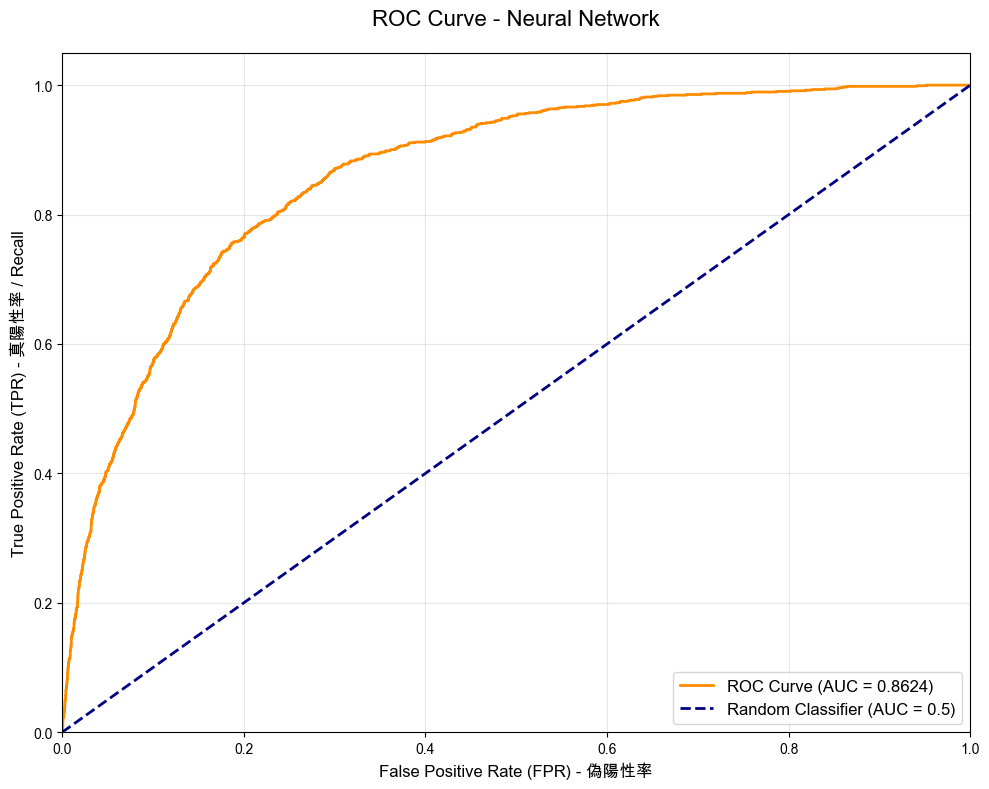

ROC Curve & AUC 分析結果:

AUC (Area Under Curve) 分數: 0.8624
  → AUC 範圍: 0.0 ~ 1.0
  → AUC = 1.0: 完美分類器
  → AUC = 0.5: 隨機猜測（無預測能力）
  → AUC < 0.5: 比隨機猜測還差

ROC Curve 解讀:
• X 軸 (FPR): False Positive Rate = FP / (FP + TN)
  → 實際為「未訂閱」中，被誤判為「訂閱」的比例

• Y 軸 (TPR): True Positive Rate = TP / (TP + FN) = Recall
  → 實際為「訂閱」中，被正確找出的比例

• 曲線越靠近左上角越好（高 TPR、低 FPR）
• 藍色虛線：隨機分類器的基準線
• 橘色實線：我們的模型表現

AUC 評估標準:
✓ AUC = 0.8624 → 良好 (Good)

業務應用:
• 可調整分類閾值（threshold）來平衡 FPR 與 TPR
• 降低閾值 → 提高 TPR (找到更多訂閱客戶) 但 FPR 也上升
• 提高閾值 → 降低 FPR (減少誤判) 但 TPR 也下降
• 預設閾值 = 0.5，可根據業務需求調整

不同閾值下的 TPR 與 FPR (前 5 個閾值):
      閾值 |    TPR (Recall) |        FPR
----------------------------------------
     inf |          0.0000 |     0.0000
  0.6932 |          0.0000 |     0.0001
  0.6826 |          0.0019 |     0.0001
  0.6757 |          0.0019 |     0.0002
  0.6679 |          0.0058 |     0.0002


In [55]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# 取得預測機率（正類的機率）
# TensorFlow 模型已經輸出機率值，直接使用
y_pred_proba_nn = y_pred_proba_raw

# 計算 ROC 曲線的數據點
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test, y_pred_proba_nn)

# 計算 AUC 分數
roc_auc_nn = auc(fpr_nn, tpr_nn)

# 繪製 ROC 曲線
plt.figure(figsize=(10, 8))
plt.plot(fpr_nn, tpr_nn, color='darkorange', lw=2, 
         label=f'ROC Curve (AUC = {roc_auc_nn:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR) - 偽陽性率', fontsize=12)
plt.ylabel('True Positive Rate (TPR) - 真陽性率 / Recall', fontsize=12)
plt.title('ROC Curve - Neural Network', fontsize=16, pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 詳細說明
print("=" * 70)
print("ROC Curve & AUC 分析結果:")
print("=" * 70)
print(f"\nAUC (Area Under Curve) 分數: {roc_auc_nn:.4f}")
print(f"  → AUC 範圍: 0.0 ~ 1.0")
print(f"  → AUC = 1.0: 完美分類器")
print(f"  → AUC = 0.5: 隨機猜測（無預測能力）")
print(f"  → AUC < 0.5: 比隨機猜測還差")

print("\n" + "=" * 70)
print("ROC Curve 解讀:")
print("=" * 70)
print("• X 軸 (FPR): False Positive Rate = FP / (FP + TN)")
print("  → 實際為「未訂閱」中，被誤判為「訂閱」的比例")
print("\n• Y 軸 (TPR): True Positive Rate = TP / (TP + FN) = Recall")
print("  → 實際為「訂閱」中，被正確找出的比例")
print("\n• 曲線越靠近左上角越好（高 TPR、低 FPR）")
print("• 藍色虛線：隨機分類器的基準線")
print("• 橘色實線：我們的模型表現")

print("\n" + "=" * 70)
print("AUC 評估標準:")
print("=" * 70)
if roc_auc_nn >= 0.9:
    print(f"✓ AUC = {roc_auc_nn:.4f} → 優秀 (Excellent)")
elif roc_auc_nn >= 0.8:
    print(f"✓ AUC = {roc_auc_nn:.4f} → 良好 (Good)")
elif roc_auc_nn >= 0.7:
    print(f"○ AUC = {roc_auc_nn:.4f} → 尚可 (Fair)")
elif roc_auc_nn >= 0.6:
    print(f"△ AUC = {roc_auc_nn:.4f} → 不佳 (Poor)")
else:
    print(f"✗ AUC = {roc_auc_nn:.4f} → 失敗 (Fail)")

print("\n" + "=" * 70)
print("業務應用:")
print("=" * 70)
print("• 可調整分類閾值（threshold）來平衡 FPR 與 TPR")
print("• 降低閾值 → 提高 TPR (找到更多訂閱客戶) 但 FPR 也上升")
print("• 提高閾值 → 降低 FPR (減少誤判) 但 TPR 也下降")
print(f"• 預設閾值 = 0.5，可根據業務需求調整")

# 顯示幾個關鍵閾值點
print("\n" + "=" * 70)
print("不同閾值下的 TPR 與 FPR (前 5 個閾值):")
print("=" * 70)
print(f"{'閾值':>8} | {'TPR (Recall)':>15} | {'FPR':>10}")
print("-" * 40)
for i in range(min(5, len(thresholds_nn))):
    print(f"{thresholds_nn[i]:>8.4f} | {tpr_nn[i]:>15.4f} | {fpr_nn[i]:>10.4f}")

# 訓練過程視覺化

顯示訓練過程中的損失函數和準確率變化，幫助判斷模型是否有過擬合或欠擬合的問題。

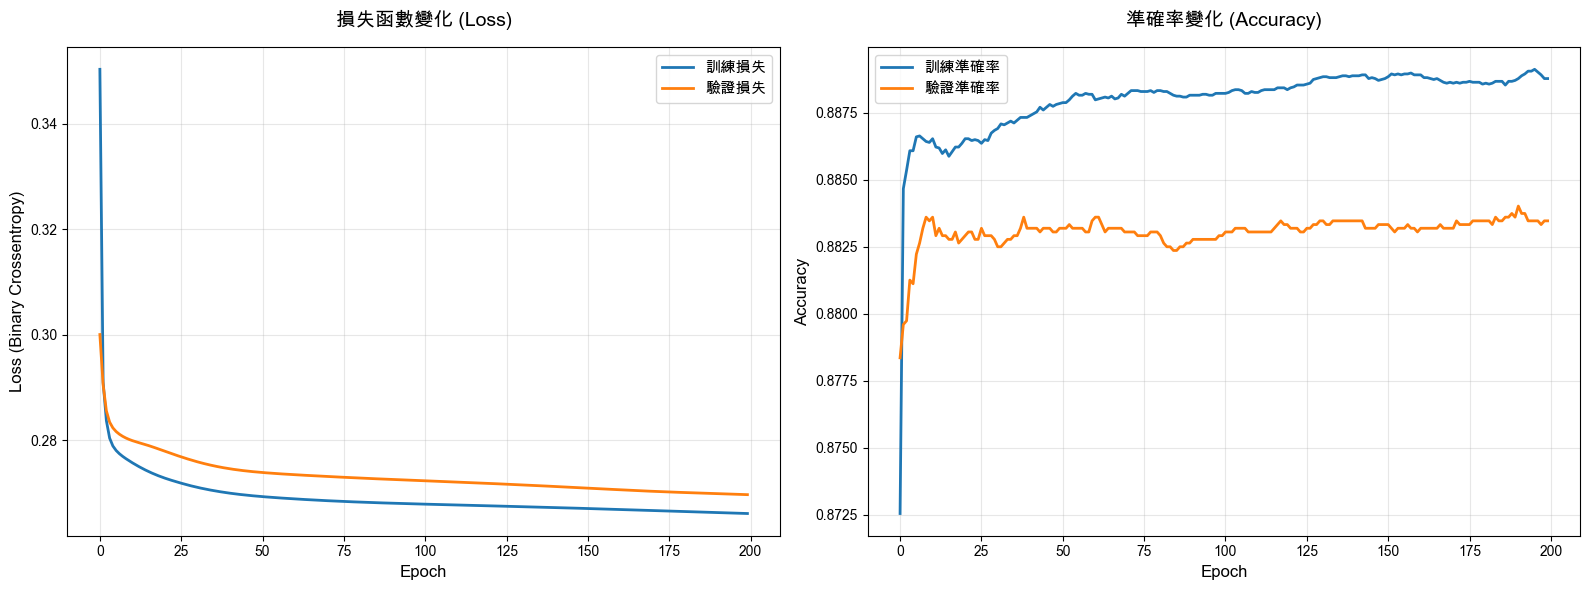

訓練過程分析:

最終結果 (Epoch 200):
  訓練損失: 0.2661
  驗證損失: 0.2697
  訓練準確率: 0.8888 (88.88%)
  驗證準確率: 0.8835 (88.35%)

最佳驗證損失: 0.2697 (Epoch 200)

模型評估:
✓ 模型訓練良好:
  → 訓練損失與驗證損失接近
  → 沒有明顯的過擬合或欠擬合

✓ 訓練準確率與驗證準確率接近，模型穩定


In [56]:
# 繪製訓練過程
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左圖: 損失函數變化
axes[0].plot(history.history['loss'], label='訓練損失', linewidth=2)
axes[0].plot(history.history['val_loss'], label='驗證損失', linewidth=2)
axes[0].set_title('損失函數變化 (Loss)', fontsize=14, pad=15)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# 右圖: 準確率變化
axes[1].plot(history.history['accuracy'], label='訓練準確率', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='驗證準確率', linewidth=2)
axes[1].set_title('準確率變化 (Accuracy)', fontsize=14, pad=15)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 分析訓練過程
print("=" * 70)
print("訓練過程分析:")
print("=" * 70)

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

min_val_loss = min(history.history['val_loss'])
min_val_loss_epoch = history.history['val_loss'].index(min_val_loss) + 1

print(f"\n最終結果 (Epoch {len(history.history['loss'])}):")
print(f"  訓練損失: {final_train_loss:.4f}")
print(f"  驗證損失: {final_val_loss:.4f}")
print(f"  訓練準確率: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  驗證準確率: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")

print(f"\n最佳驗證損失: {min_val_loss:.4f} (Epoch {min_val_loss_epoch})")

# 判斷是否過擬合
loss_diff = final_train_loss - final_val_loss
acc_diff = final_train_acc - final_val_acc

print("\n" + "=" * 70)
print("模型評估:")
print("=" * 70)

if loss_diff < -0.05:
    print("⚠️  可能有「欠擬合」(Underfitting):")
    print("    → 訓練損失 > 驗證損失")
    print("    → 建議: 增加網路層數/神經元數量、訓練更多 epoch")
elif loss_diff > 0.1:
    print("⚠️  可能有「過擬合」(Overfitting):")
    print("    → 訓練損失 < 驗證損失 (差距較大)")
    print("    → 建議: 加入 Dropout、減少網路複雜度、使用 Early Stopping")
else:
    print("✓ 模型訓練良好:")
    print("  → 訓練損失與驗證損失接近")
    print("  → 沒有明顯的過擬合或欠擬合")

if acc_diff > 0.05:
    print("\n⚠️  訓練準確率明顯高於驗證準確率")
    print("    → 模型可能對訓練資料過度擬合")
elif acc_diff < -0.05:
    print("\n⚠️  驗證準確率高於訓練準確率")
    print("    → 不常見，可能需要檢查資料劃分")
else:
    print("\n✓ 訓練準確率與驗證準確率接近，模型穩定")

## TensorFlow/Keras 神經網路說明

### **什麼是神經網路 (Neural Network)？**
神經網路是受生物神經元啟發的機器學習模型，由多層神經元組成，能夠學習複雜的非線性關係。

### **模型架構：**
本模型使用 **Sequential API** 建立：
1. **輸入層 (Input Layer)**：自動根據特徵數量調整
2. **隱藏層 (Hidden Layers)**：3層，每層5個神經元，使用 ReLU 激活函數
3. **輸出層 (Output Layer)**：1個神經元，使用 Sigmoid 激活函數（輸出 0~1 的機率）

### **關鍵參數：**

**1. 激活函數 (Activation Function)**
- **ReLU** (Rectified Linear Unit): `f(x) = max(0, x)`
  - 優點：計算快速、緩解梯度消失問題
  - 適用：隱藏層
- **Sigmoid**: `f(x) = 1 / (1 + e^-x)`
  - 優點：輸出範圍 0~1，適合機率預測
  - 適用：二元分類的輸出層

**2. 優化器 (Optimizer)**
- **Adam** (Adaptive Moment Estimation)
  - 自適應學習率，結合 Momentum 和 RMSprop 優點
  - 通常是神經網路的首選優化器

**3. 損失函數 (Loss Function)**
- **Binary Crossentropy**：二元分類專用
  - 衡量預測機率與真實標籤之間的差距

**4. 訓練參數**
- **Epoch**：完整遍歷訓練資料的次數（本例：100次）
- **Batch Size**：每次更新權重使用的樣本數（本例：32筆）
- **Validation Split**：從訓練資料中分出驗證集的比例（本例：20%）

### **TensorFlow vs scikit-learn 的差異：**

| 特性 | TensorFlow/Keras | scikit-learn (MLPClassifier) |
|------|------------------|------------------------------|
| **彈性** | 高（可自定義網路架構） | 低（預設架構） |
| **訓練過程** | 可視覺化（loss/accuracy curve） | 無法直接視覺化 |
| **GPU 加速** | 支援 | 不支援 |
| **模型儲存** | 完整模型儲存 (.h5, SavedModel) | pickle 儲存 |
| **部署** | 支援多平台（TensorFlow Lite, TF.js） | 受限 |
| **學習曲線** | 較陡峭 | 較平緩 |

### **優點 ✓**
- 完全掌控網路架構（層數、神經元數、激活函數等）
- 可視覺化訓練過程，及早發現過擬合
- 支援 GPU 加速，適合大規模資料
- 容易加入進階技術（Dropout、Batch Normalization、Early Stopping）
- 業界標準，適合產品部署

### **缺點 ✗**
- 需要更多程式碼
- 訓練時間可能較長（小資料集上）
- 需要更多超參數調整經驗
- 對初學者較複雜

### **何時選用 TensorFlow？**
- 需要自定義網路架構
- 資料量大（> 10,000 筆）
- 需要 GPU 加速
- 需要部署到生產環境
- 需要視覺化訓練過程

### **何時選用 scikit-learn？**
- 快速原型開發
- 資料量小
- 需要簡單易用的 API
- 不需要複雜的網路架構